# notebook to fit psd power law to correspondingly scaled core flow fields


# preamble

In [1]:
'''
for all waves - compute their analytic field sv, utheta and uphi psd (i.e. power at bin width df = 1)
Then fit a power law to the corresponding flow data
Then store this as power scaling utheta, uphi respectively
pass these coefficients to the noise generation via component flagging approach
'''

'\nfor all waves - compute their analytic field sv, utheta and uphi psd (i.e. power at bin width df = 1)\nThen fit a power law to the corresponding flow data\nThen store this as power scaling utheta, uphi respectively\npass these coefficients to the noise generation via component flagging approach\n'

In [2]:
# -----------------------------------------------------------------------
# PUT AT START OF EVERY NOTEBOOK FOR MSC THESIS PROJECT

# dependencies
import pickle
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import chaosmagpy as cp
import pydmd
import cmath
import copy
import h5py
import math
from scipy.signal import periodogram
from matplotlib.animation import FuncAnimation
from IPython.display import Video
from tqdm.notebook import tqdm

# define root path from which all relative paths are set
PROJECT_ROOT = Path("/home/jovyan/MSc Thesis/working_directory")
# adding project root to list of locations to search for when
# importing libraries
sys.path.append(str(PROJECT_ROOT)) 
# paths for:
# data
DATA_DIR = PROJECT_ROOT / "data"
# outputs
OUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUT_DIR/"figures"
# specific data directories
FELIX_DIR = DATA_DIR / "modes_surface"
CHAOS_DIR = DATA_DIR / "chaos_mats"

# importing all of the files from thesis utilities for use
from thesis_utils.sdm import * # use one single python file for all functions

# auto-update any changes to utilities code
%load_ext autoreload
%autoreload 2

# -----------------------------------------------------------------------

In [3]:
# defining time parameters

# note: times relative to start of synthetic time series (i.e. t=0)
t_start = 0.0 # start time
t_end = 25.0 # end time
t_record = t_end - t_start # record length
f_bin = 1 / t_record # associatied fourier resolution

dt_years = 0.5   # 6-month sampling (same as CHAOS independent information)
f_sample = 1 / dt_years    # samples per year

# getting decimal year and julian date formats
times_dyear = np.arange(t_start, t_end, dt_years)
n_times = int(len(times_dyear)) # number of total samples
print(n_times)
# choosing if decay on or not (globally)
decay = False

if decay:
    sigma='default'
else:
    sigma=0

# select desired modes:
input_modes_global = np.arange(1,63,1)


50


In [4]:
# make array to store recovered eigenvalues for each component
eig_array = np.zeros((len(input_modes_global), 4),dtype=complex)

# true vs recovered spatial pattern:
# make array to store (normalised?) difference
norm_diff_array = np.zeros((len(input_modes_global), 3))

# make array to store correlation coefficient 
corr_array = np.zeros((len(input_modes_global), 3))

# ------------------- MAIN DATA RETRIEVAL -------------------------------

input_wave_data = []

# for each input mode, add it to total data storage
for i, mode_number in enumerate(tqdm(input_modes_global)):

    mode_i_data = [mode_number]

    br, sv, utheta, uphi, eigenvalue = Felix_Wave_Obtain(times_dyear, mode_number,bin_choice='wave-centred', sigma=sigma)

    mode_i_data = {
        "mode_number": mode_number,
        "br": br,
        "sv": sv,
        "utheta": utheta,
        "uphi": uphi,
        "eigenvalue": eigenvalue,
        # filled later
        "best_match_idx": { # list as need to store for each noise realisation
            "br": [],
            "sv": [],
            "utheta": [],
            "uphi": []
        }
    }

    input_wave_data.append(mode_i_data) # input_wave_data = data dictionary for mode i
    
# getting total inputs
# could really properly implement SV here
tot_input_br = Total_Input_Evaluate(input_wave_data, times_dyear, "br")
tot_input_sv = Total_Input_Evaluate(input_wave_data, times_dyear, "sv")
# use SV instead of mainfield, for waves it is just phase shifted Br, therefore no advantage to MF/Br
tot_input_utheta = Total_Input_Evaluate(input_wave_data, times_dyear, "utheta")
tot_input_uphi = Total_Input_Evaluate(input_wave_data, times_dyear, "uphi")

# get power quality control
#Power_QC(tot_input_sv, times_dyear, input_wave_freqs, scaling='spectrum')

  0%|          | 0/62 [00:00<?, ?it/s]

## Explanation:

- below code goes through all of the power law scaled (SV-based) felix wave input modes
- for each one it retrieves the analytical (phasor derived) power over one period
- it does this for all 3 components
- you can then divide this power by the bin width  to get a psd for a particular sampling regime (?)
- so should fit a power law to these analytical powers, divide by chaos sampling level to get psd you want (as scaling based on chaos sampling)

In [5]:
full_power_suite = Felix_Power_Suite(input_wave_data)

In [17]:
wave_power_suite = full_power_suite[:-1]
f = np.asarray([data_row["frequency"] for data_row in wave_power_suite])

In [18]:
psd_by_component = {
    "frequency":f, 
    "psd":{
        "sv":None,
        "utheta":None,
        "uphi":None,
    }
}

In [19]:
for c in psd_by_component["psd"]:
    psd_by_component["psd"][c]=np.asarray([data_row["field_power"][c] for data_row in wave_power_suite])/ (1/25)

In [20]:
import numpy as np


def Branched_Power_Law_Fit(f, P, f_branch):
    """
    Fit a continuous branched power law:

        P(f) = A1 f^k1,  f <= f_branch
        P(f) = A2 f^k2,  f >  f_branch

    Continuity is enforced at f_branch:

        A1 f_branch^k1 = A2 f_branch^k2

    Fit is done in log10-log10 space.

    Returns A1, k1, A2, k2 in ordinary power-law form.
    """

    f = np.asarray(f, dtype=float)
    P = np.asarray(P, dtype=float)

    mask = (
        np.isfinite(f) &
        np.isfinite(P) &
        (f > 0) &
        (P > 0)
    )

    f_used = f[mask]
    P_used = P[mask]

    logf = np.log10(f_used)
    logP = np.log10(P_used)

    logfb = np.log10(f_branch)

    # Model:
    # logP = logPb + k1 * (logf - logfb), for f <= fb
    # logP = logPb + k2 * (logf - logfb), for f >  fb
    #
    # Unknowns are:
    # m = [logPb, k1, k2]
    #
    # This enforces continuity automatically because both branches pass
    # through (logfb, logPb).

    low_mask = f_used <= f_branch
    high_mask = f_used > f_branch

    if np.sum(low_mask) < 2:
        raise ValueError("Need at least two valid points below or at f_branch.")

    if np.sum(high_mask) < 2:
        raise ValueError("Need at least two valid points above f_branch.")

    G = np.zeros((len(f_used), 3))

    # intercept at branch point
    G[:, 0] = 1.0

    # low-frequency slope contribution
    G[low_mask, 1] = logf[low_mask] - logfb

    # high-frequency slope contribution
    G[high_mask, 2] = logf[high_mask] - logfb

    # least-squares fit
    logPb, k1, k2 = np.linalg.lstsq(G, logP, rcond=None)[0]

    # Convert branch-point intercept to ordinary A values:
    #
    # log10(Pb) = log10(A1) + k1 log10(fb)
    # log10(Pb) = log10(A2) + k2 log10(fb)

    log10_A1 = logPb - k1 * logfb
    log10_A2 = logPb - k2 * logfb

    A1 = 10**log10_A1
    A2 = 10**log10_A2

    # diagnostics
    logP_pred = G @ np.array([logPb, k1, k2])
    residuals = logP - logP_pred

    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((logP - np.mean(logP))**2)

    r2_log = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    rmse_log10 = np.sqrt(np.mean(residuals**2))
    mae_log10 = np.mean(np.abs(residuals))

    result = {
        "A1": A1,
        "k1": k1,
        "A2": A2,
        "k2": k2,
    }

    return result

In [21]:
def Empty_PSD_Dict():
    return {
        "A1": [],
        "A2": [],
        "k1": [],
        "k2": []
    }

def PSD_Dict_Fill(psd_dict, c, A1, A2, k1, k2):
    psd_dict[c]["A1"] = A1
    psd_dict[c]["A2"] = A2
    psd_dict[c]["k1"] = k1
    psd_dict[c]["k2"] = k2
    return psd_dict

In [22]:
power_law_psd_dict = {
    "sv":Empty_PSD_Dict(),
    "utheta":Empty_PSD_Dict(),
    "uphi":Empty_PSD_Dict(),
    "f_branch":1/12
}

In [23]:
# setting the sv psd to be from the power law
with open(f"{DATA_DIR}/observational_sv_psd.pkl", "rb") as f:
    observational_sv_psd = pickle.load(f)
    
PSD_Dict_Fill(power_law_psd_dict, "sv", observational_sv_psd["A1"], observational_sv_psd["A2"], observational_sv_psd["k1"], observational_sv_psd["k2"])

{'sv': {'A1': np.float64(27086.043360943346),
  'A2': np.float64(41.766061446047495),
  'k1': np.float64(-3.6715741379757616),
  'k2': np.float64(-6.277180987237862)},
 'utheta': {'A1': [], 'A2': [], 'k1': [], 'k2': []},
 'uphi': {'A1': [], 'A2': [], 'k1': [], 'k2': []},
 'f_branch': 0.08333333333333333}

In [24]:
branch = 1/12 # /yr
freq = psd_by_component["frequency"]

for c in ["utheta", "uphi"]:
    result = Branched_Power_Law_Fit(freq, psd_by_component["psd"][c], branch)
    PSD_Dict_Fill(power_law_psd_dict, c, result["A1"], result["A2"], result["k1"], result["k2"])

In [25]:
print(power_law_psd_dict)

{'sv': {'A1': np.float64(27086.043360943346), 'A2': np.float64(41.766061446047495), 'k1': np.float64(-3.6715741379757616), 'k2': np.float64(-6.277180987237862)}, 'utheta': {'A1': np.float64(2.307535623352783e-05), 'A2': np.float64(3.941910801007935e-07), 'k1': np.float64(-4.293668659158364), 'k2': np.float64(-5.931430275298377)}, 'uphi': {'A1': np.float64(0.00013415868705850406), 'A2': np.float64(2.609365385170884e-06), 'k1': np.float64(-4.186133872572136), 'k2': np.float64(-5.771672825148968)}, 'f_branch': 0.08333333333333333}


In [26]:
import pickle

with open(f"{DATA_DIR}/power_law_psd_dict.pkl", "wb") as f:
    pickle.dump(power_law_psd_dict, f)



In [27]:
# load elsewhere:
import pickle

with open(f"{DATA_DIR}/power_law_psd_dict.pkl", "rb") as f:
    performance_summary = pickle.load(f)

In [ ]:
## when you look here again - do plots of each data set against hte derived power law for it

In [28]:
import numpy as np
import matplotlib.pyplot as plt


def evaluate_broken_power_law(f, A1, A2, k1, k2, f_branch):
    """
    Evaluate broken power law.

    Assumes:
      branch 1: f <= f_branch uses A1 * f**k1
      branch 2: f >  f_branch uses A2 * f**k2
    """

    f = np.asarray(f, dtype=float)

    psd = np.full_like(f, np.nan, dtype=float)

    low_mask = f <= f_branch
    high_mask = f > f_branch

    psd[low_mask] = A1 * f[low_mask]**k1
    psd[high_mask] = A2 * f[high_mask]**k2

    return psd


def plot_power_law_with_analytic_wave_psd(
    power_law_psd_dict,
    psd_by_component,
    save_path=None,
    show=True
):
    """
    Plot power-law PSD curves and analytic wave PSD estimates for sv, utheta, uphi.
    """

    components = ["sv", "utheta", "uphi"]

    component_labels = {
        "sv": r"$\dot{B}_r$",
        "utheta": r"$u_\theta$",
        "uphi": r"$u_\phi$"
    }

    component_colours = {
        "sv": "blue",
        "utheta": "green",
        "uphi": "red"
    }

    f_branch = power_law_psd_dict["f_branch"]

    f_wave = np.asarray(psd_by_component["frequency"], dtype=float)

    # frequency range for smooth PSD curves
    f_min = np.nanmin(f_wave[f_wave > 0])
    f_max = np.nanmax(f_wave)

    # include branch frequency in range if relevant
    f_min = min(f_min, f_branch) / 1.3
    f_max = max(f_max, f_branch) * 1.3

    f_plot = np.logspace(
        np.log10(f_min),
        np.log10(f_max),
        500
    )

    fig, axes = plt.subplots(
        3, 1,
        figsize=(8, 12),
        dpi=200,
        sharex=True
    )

    for ax, c in zip(axes, components):

        A1 = power_law_psd_dict[c]["A1"]
        A2 = power_law_psd_dict[c]["A2"]
        k1 = power_law_psd_dict[c]["k1"]
        k2 = power_law_psd_dict[c]["k2"]

        psd_fit = evaluate_broken_power_law(
            f_plot,
            A1=A1,
            A2=A2,
            k1=k1,
            k2=k2,
            f_branch=f_branch
        )

        psd_wave = np.asarray(psd_by_component["psd"][c], dtype=float)

        wave_mask = (
            np.isfinite(f_wave)
            & np.isfinite(psd_wave)
            & (f_wave > 0)
            & (psd_wave > 0)
        )

        ax.loglog(
            f_plot,
            psd_fit,
            color=component_colours[c],
            linewidth=2,
            label="Power-law PSD"
        )

        ax.scatter(
            f_wave[wave_mask],
            psd_wave[wave_mask],
            color=component_colours[c],
            edgecolor="black",
            s=70,
            zorder=3,
            label="Analytic wave PSD"
        )

        ax.axvline(
            f_branch,
            color="black",
            linestyle="--",
            linewidth=1,
            alpha=0.7,
            label=r"$f_{\mathrm{branch}}$" if c == "sv" else None
        )

        ax.set_ylabel("PSD")
        ax.set_title(component_labels[c])
        ax.grid(True, which="both", alpha=0.35)
        ax.legend()

    axes[-1].set_xlabel(r"Frequency [yr$^{-1}$]")

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

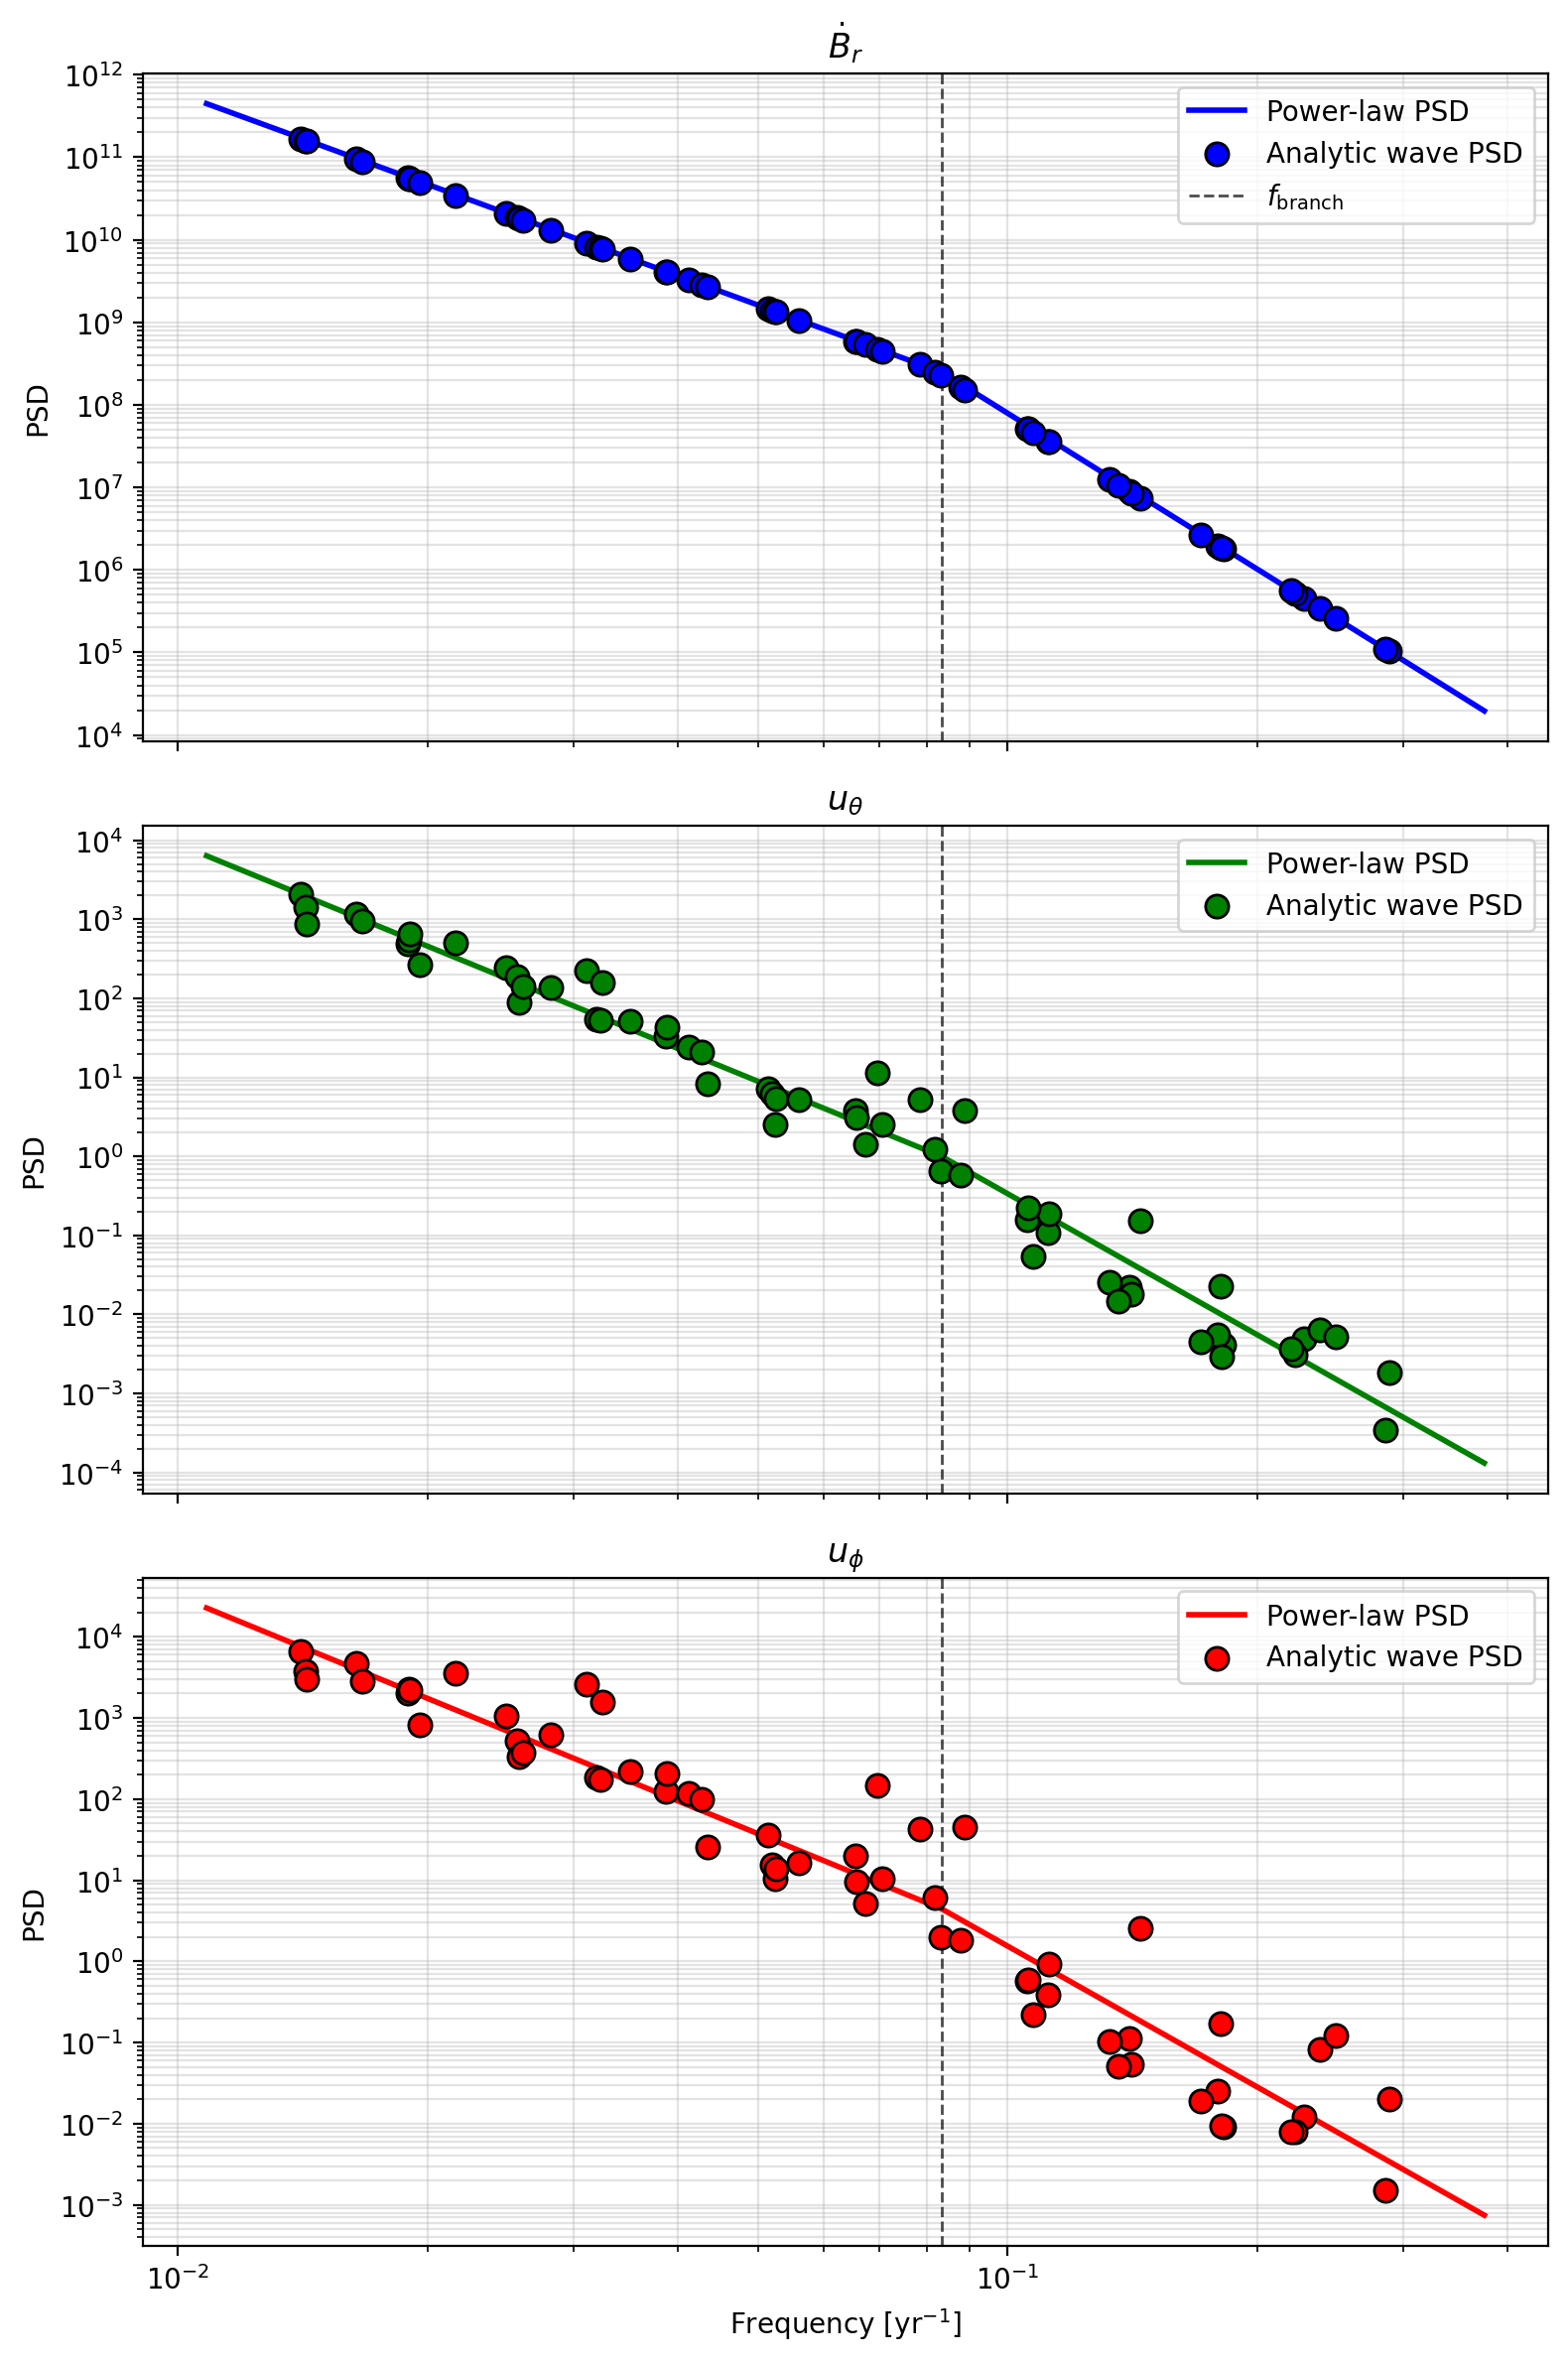

In [29]:
plot_power_law_with_analytic_wave_psd(
    power_law_psd_dict,
    psd_by_component,
    save_path="figures/power_law_vs_analytic_wave_psd.png",
    show=True
)